## **Assignment 1: Generative Deep Learning - 708.088 (SS26)**
**Authored by:** Ozan Özdenizci, Institute of Machine Learning and Neural Computation, TU Graz

**Assignment issued on:** March 19th, 2026 09:00 AM\
**Assignment deadline:** April 16th, 2026 09:00 AM

# Training a VQ-VAE with an Autoregressive Prior

Vector-quantized variational autoencoders (VQ-VAE) combined with an autoregressive prior over the discrete latent space.


In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(42)
np.random.seed(42)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1).float())
])

train_data = torchvision.datasets.MNIST(root='data/', train=True, transform=transform, download=True)
test_data = torchvision.datasets.MNIST(root='data/', train=False, transform=transform, download=True)

train_data, val_data = torch.utils.data.random_split(train_data, [55000, 5000])

training_loader = DataLoader(train_data, batch_size=128, shuffle=True)# shuffle needed because digits might be ordered in training set
val_loader = DataLoader(val_data, batch_size=128, shuffle=False)
test_loader = DataLoader(test_data, batch_size=128, shuffle=False)

### Part (a): VQ-VAE architecture

In [ ]:
class Encoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim, num_latents):
        super(Encoder, self).__init__()
        self.num_latents = num_latents
        self.latent_dim = latent_dim
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LeakyReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(),
            nn.Linear(hidden_dim, num_latents * latent_dim)#sets the dimension of the encoded embeddings
        )

    def forward(self, x):
        #hidden_dim B ... batch size
        #num_latents L ... number of latent vectors
        #latent_dim D ... dimension of each latent vector

        h = self.net(x) # [B , L*D] passes input through encoder to get latent embeddings
        return h.reshape(x.shape[0], self.num_latents, self.latent_dim)# [B, L, D], sequences of latent vectors
        #retursn z_e

class Decoder(nn.Module):
    def __init__(self, latent_dim, num_latents, hidden_dim, output_dim):
        super(Decoder, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(num_latents * latent_dim, hidden_dim), # [L*D, B]
            nn.LeakyReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(),
            nn.Linear(hidden_dim, output_dim),
            nn.Sigmoid()
        )

    def forward(self, z_q):
        B, L, D = z_q.shape
        z_q_flat = z_q.reshape(B, L * D) #concatenates latent vectors
        return self.net(z_q_flat)
        #returns x_hat


class VectorQuantizer(nn.Module):
    def __init__(self, K, D, beta=0.25):
        super(VectorQuantizer, self).__init__()
        self.K = K          # number of codebook entries
        self.D = D          # dimensionality of each codebook entry
        self.beta = beta    # commitment loss weight

        # codebook with K entries each of dimension D
        self.embedding = nn.Embedding(K, D)
        self.embedding.weight.data.uniform_(-1.0 / K, 1.0 / K)

    def forward(self, z_e):
        B, L, D = z_e.shape   # batch size x latent sequence length x dim of codebook vectors

        # TODO: Compute distances between encoder outputs and codebook entries.
        # Find nearest codebook entry for each position
        # indices: codebook indices of shape (B, L)
        #combine all batches
        z_e_comb = z_e.reshape(B*L, D)
        # more compact way of calculating squared euclidean distance, but root is taken first
        distances = torch.cdist(z_e_comb, self.embedding.weight).pow(2)# [B*L,K]
        indices = torch.argmin(distances,dim =1) # [B*L,1]

        # z_q: quantized output, should be same shape as z_e
        z_q = self.embedding(indices)
        z_q = z_q.reshape(B,L,D)

        # TODO: Compute VQ loss: codebook loss + beta * commitment losss
        # Codebook loss: moves codebook entries toward encoder outputs
        # Commitment loss: moves encoder outputs toward codebook entries
        cb_loss = F.mse_loss(z_e.detach(),z_q)
        comm_loss = F.mse_loss(z_e,z_q.detach())

        vq_loss = cb_loss + self.beta * comm_loss

        # Straight-through estimator: copy gradients from z_q to z_e
        z_q = z_e + (z_q - z_e).detach()

        return z_q, indices.reshape(B, L), vq_loss
        #resturns z_q

In [12]:
class VQVAE(nn.Module):
    def __init__(self, encoder, decoder, quantizer):
        super(VQVAE, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.quantizer = quantizer

    def forward(self, x, reduction='avg'):
        z_e = self.encoder(x)
        z_q, indices, vq_loss = self.quantizer(z_e)
        x_recon = self.decoder(z_q)

        recon_loss = F.binary_cross_entropy(x_recon, x, reduction='none').sum(-1)

        if reduction == 'avg':
            return recon_loss.mean() + vq_loss
        elif reduction == 'sum':
            return recon_loss.sum() + vq_loss * x.shape[0]
        else:
            raise ValueError('reduction could be either `avg` or `sum`.')

    def encode_indices(self, x):
        with torch.no_grad():
            z_e = self.encoder(x) # each (flattened) image gets encoded into num_latent D-dimensional latent vectors
            _, indices, _ = self.quantizer(z_e) # each of the encoder latent vectors gets represented by closest codebook vector
        return indices

    def decode_indices(self, indices):
        with torch.no_grad():
            z_q = self.quantizer.embedding(indices)
            x_recon = self.decoder(z_q)
        return x_recon

In [13]:
def evaluation_vqvae(test_loader, model):
    model.eval() #switch to evaluation, with fixed weights
    loss = 0.
    N = 0.
    for i, (test_batch, _) in enumerate(test_loader):
        loss_t = model.forward(test_batch, reduction='sum')
        loss = loss + loss_t.item()
        N = N + test_batch.shape[0]
    loss = loss / N
    return loss


def training_vqvae(name, num_epochs, model, optimizer, training_loader, val_loader):
    loss_val = []

    for ep in range(num_epochs):
        model.train() #switch to training, learning weights
        for i, (batch, _) in enumerate(training_loader):
            loss = model.forward(batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        val_loss = evaluation_vqvae(val_loader, model)
        loss_val.append(val_loss)

        print(f'Epoch: {ep}, val loss={val_loss:.4f}')
        torch.save(model, name + '.model')

    return np.asarray(loss_val)

### Part (b): VQ-VAE initialization, hyperparameters and training

In [ ]:
data_dim = 784      # input dimension (28x28 images flattened)
image_dim = 28
hidden_dim = 128    # hidden layer dimensionality
num_latents = 8     # number of discrete latent positions (latent sequence length L)
D = 16              # dimensionality of each codebook entry
Ks = [8,16,32,64]             # codebook size (number of entries)
betas = [0.25,0.75]         # commitment loss weight
lr = 1e-3
num_epochs_vqvae = 100

result_dir = 'results/'
if not(os.path.exists(result_dir)):
    os.mkdir(result_dir)
name = 'vqvae'

for K in Ks:
    for beta in betas:
        encoder = Encoder(input_dim=data_dim, hidden_dim=hidden_dim, latent_dim=D, num_latents=num_latents)
        decoder = Decoder(latent_dim=D, num_latents=num_latents, hidden_dim=hidden_dim, output_dim=data_dim)
        quantizer = VectorQuantizer(K=K, D=D, beta=beta)
        vqvae = VQVAE(encoder, decoder, quantizer)

        optimizer_vqvae = torch.optim.Adam([p for p in vqvae.parameters() if p.requires_grad == True], lr=lr)

        nll_vqvae = training_vqvae(name=result_dir + name, num_epochs=num_epochs_vqvae, model=vqvae,
                                optimizer=optimizer_vqvae, training_loader=training_loader,
                                val_loader=val_loader)
        #don't hand over datasets for trianing and evaluation explicitly -> given as DataLoader object
        # --- Save model ---
        save_path = f"{result_dir}{name}_K{K}_beta{beta}.pt"
        torch.save({
            "K": K,
            "beta": beta,
            "model_state": vqvae.state_dict(),
            "optimizer_state": optimizer_vqvae.state_dict(),
            "nll": nll_vqvae
        }, save_path)

        print(f"Saved model for K={K}, beta={beta} to {save_path}")

    

Epoch: 0, val loss=987.0461
Epoch: 1, val loss=402.8229
Epoch: 2, val loss=602.8615
Epoch: 3, val loss=492.7553
Epoch: 4, val loss=435.5176
Epoch: 5, val loss=385.8959
Epoch: 6, val loss=338.7532
Epoch: 7, val loss=333.9973
Epoch: 8, val loss=314.5374
Epoch: 9, val loss=295.3180
Epoch: 10, val loss=274.0045
Epoch: 11, val loss=263.0835
Epoch: 12, val loss=252.0558
Epoch: 13, val loss=249.1343
Epoch: 14, val loss=248.1838
Epoch: 15, val loss=249.2487
Epoch: 16, val loss=240.9412
Epoch: 17, val loss=237.8159
Epoch: 18, val loss=230.6788
Epoch: 19, val loss=232.8726
Epoch: 20, val loss=223.8154
Epoch: 21, val loss=224.9299
Epoch: 22, val loss=221.8876
Epoch: 23, val loss=221.4595
Epoch: 24, val loss=220.2059
Epoch: 25, val loss=216.7525
Epoch: 26, val loss=221.0148
Epoch: 27, val loss=219.0396
Epoch: 28, val loss=218.9513
Epoch: 29, val loss=220.1156
Epoch: 30, val loss=219.2127
Epoch: 31, val loss=219.8848
Epoch: 32, val loss=219.4717
Epoch: 33, val loss=218.7955
Epoch: 34, val loss=219.

In [35]:
#loading saved models, so I don't need to retrain every time
def load_prev_model(K, beta, saved_path):
    # Setup encoder and decoder with correct parameters
    encoder = Encoder(input_dim=data_dim,hidden_dim=hidden_dim,latent_dim=D,num_latents=num_latents
    )
    decoder = Decoder(latent_dim=D,num_latents=num_latents,hidden_dim=hidden_dim,output_dim=data_dim
    )
    quantizer = VectorQuantizer(K=K, D=D, beta=beta)

    model = VQVAE(encoder, decoder, quantizer)

    # Load saved model state with certain K
    checkpoint = torch.load(saved_path, map_location="cpu",weights_only = False)
    model.load_state_dict(checkpoint["model_state"])
    model.eval()

    return model, checkpoint["nll"]


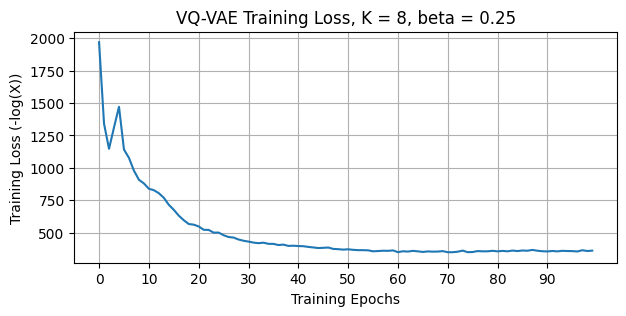

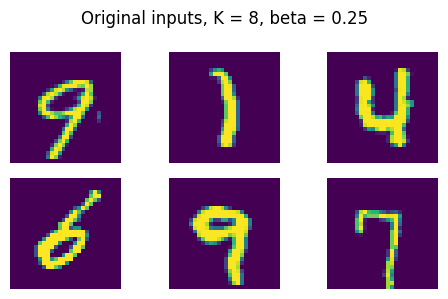

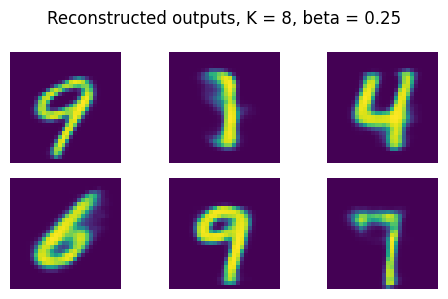

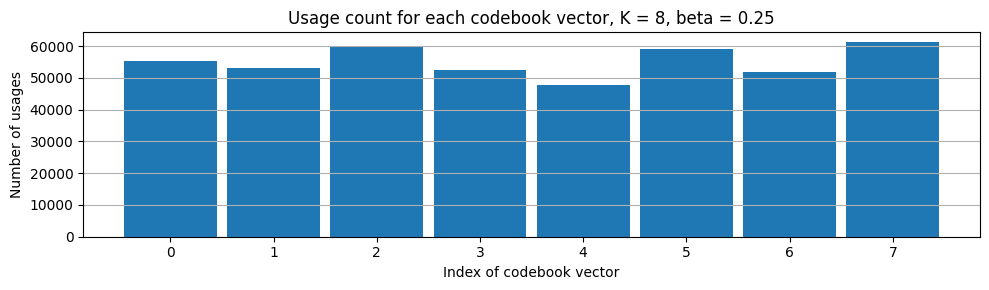

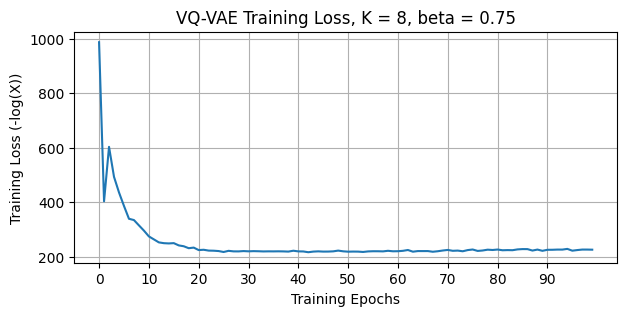

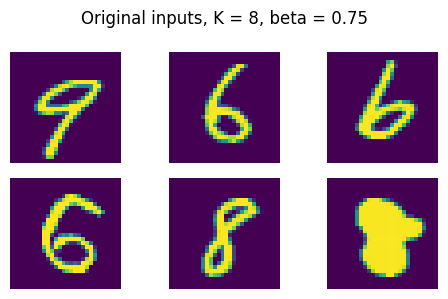

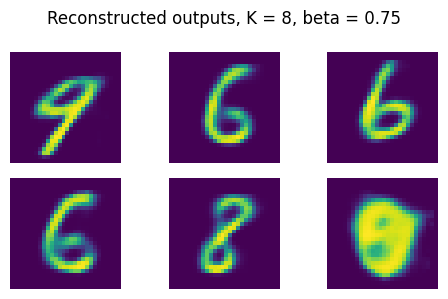

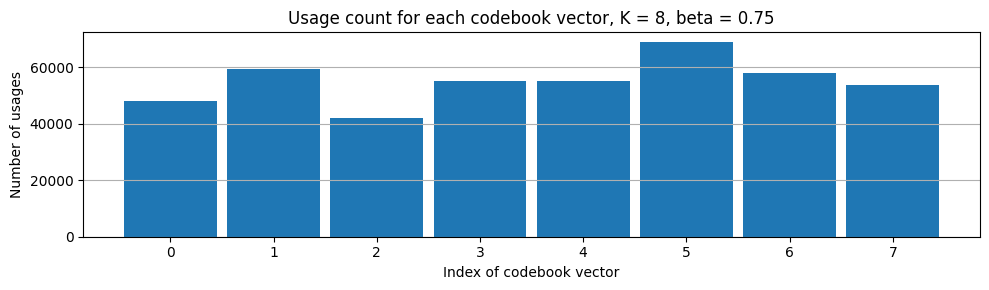

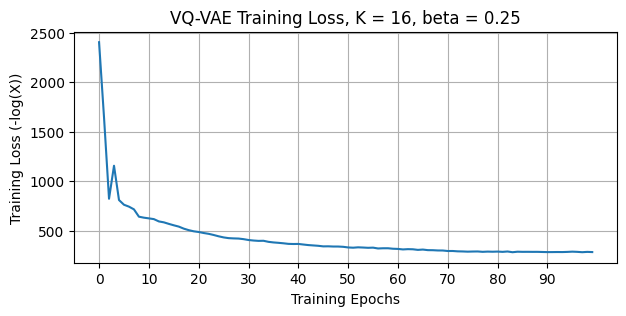

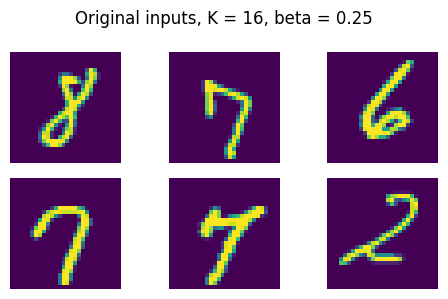

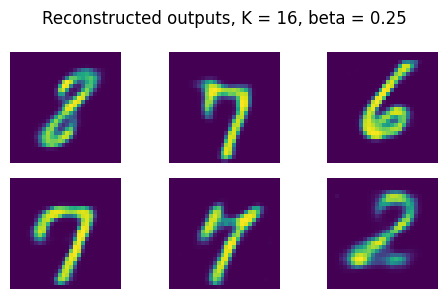

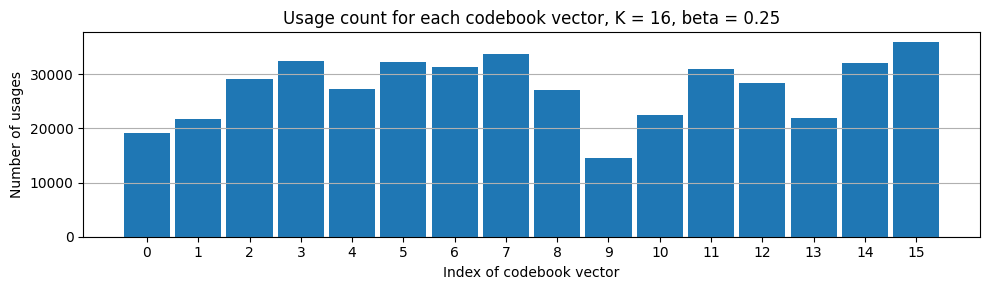

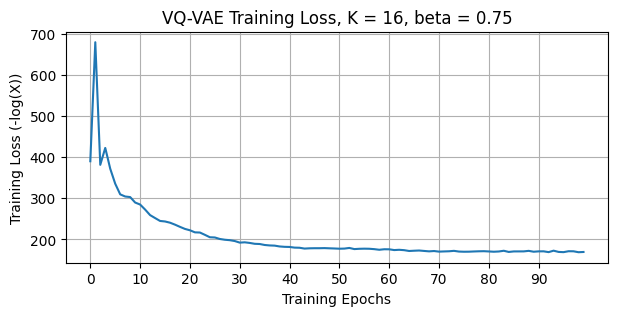

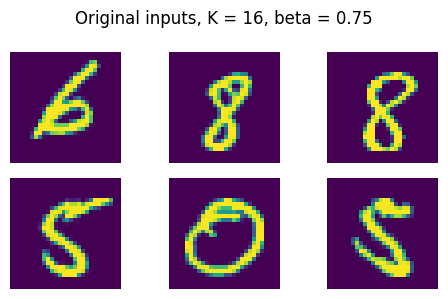

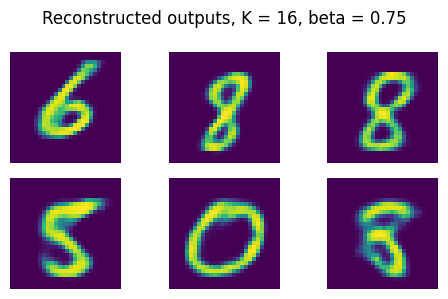

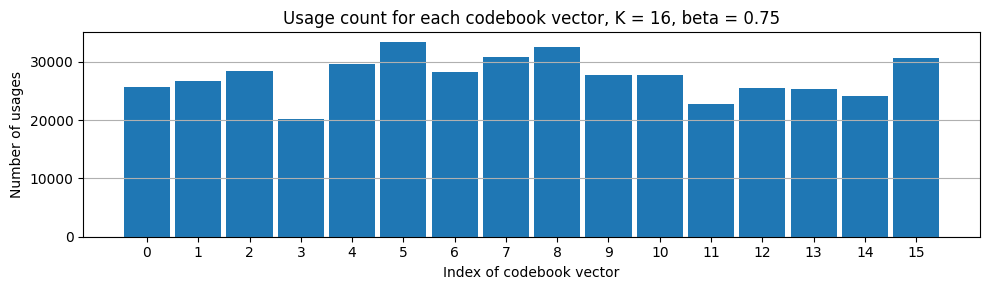

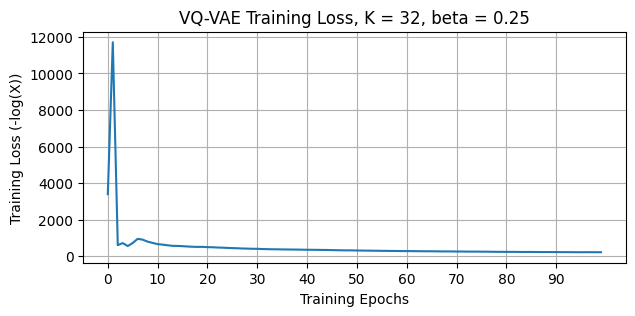

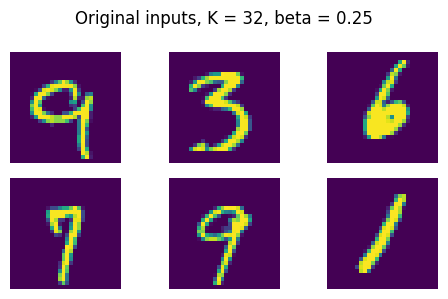

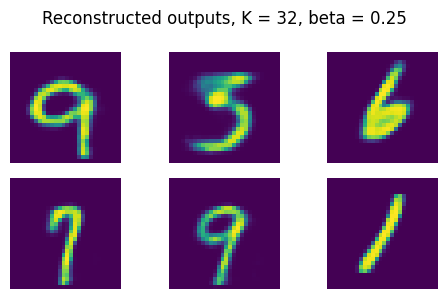

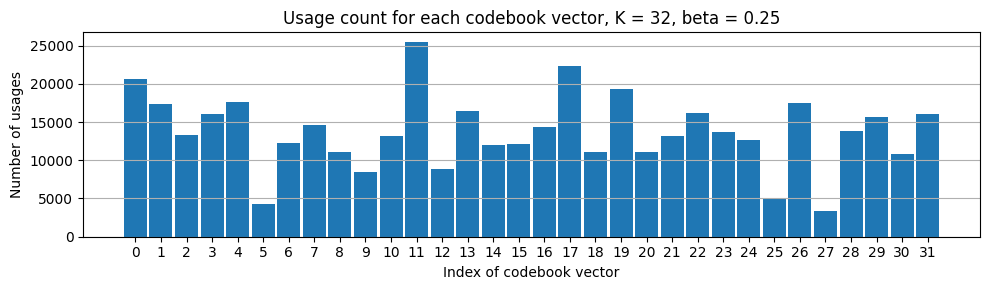

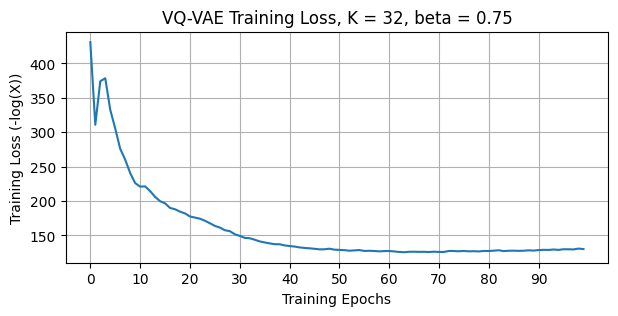

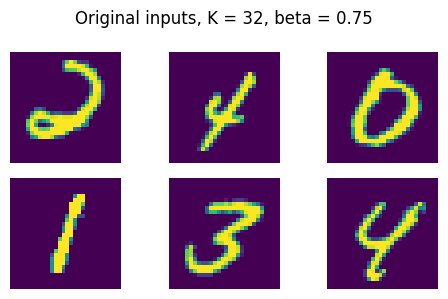

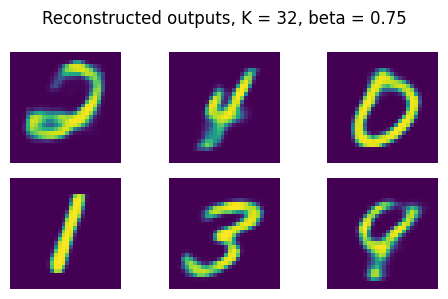

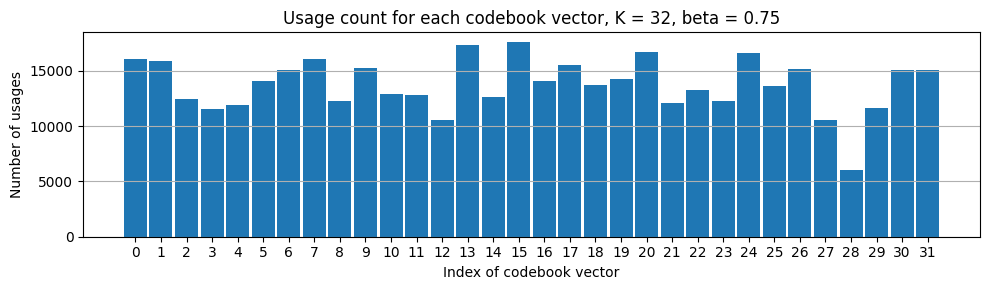

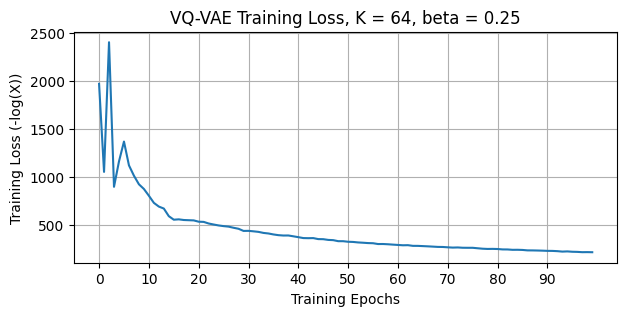

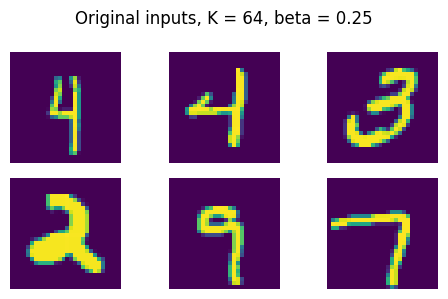

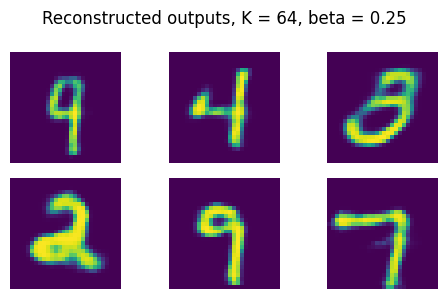

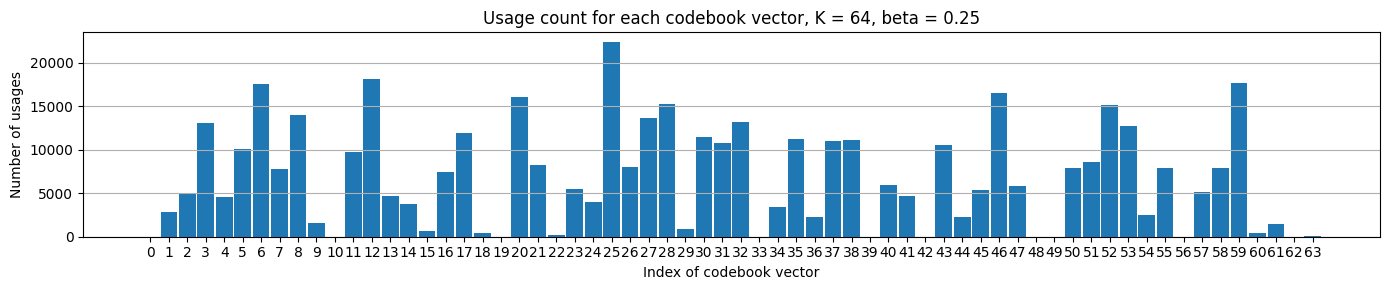

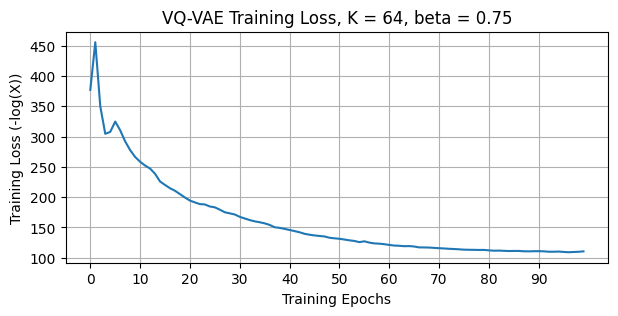

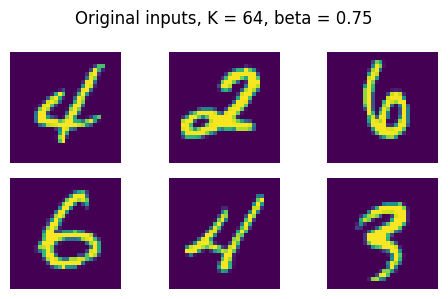

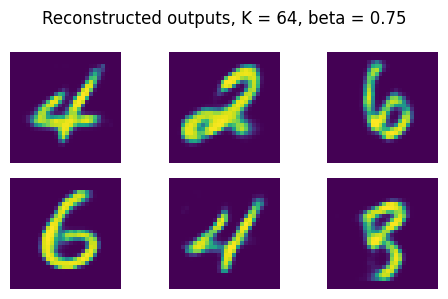

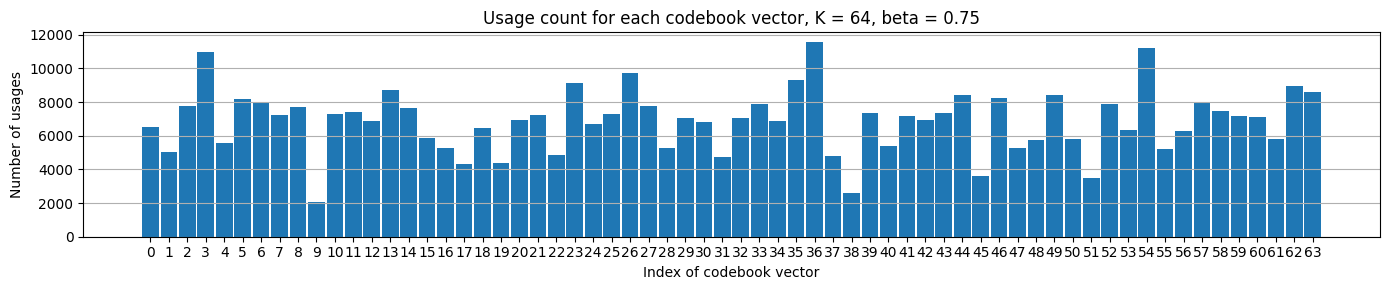

In [ ]:
#VISUALIZATION
plot_folder = "./plots/"

Ks = [8,16,32,64]
betas = [0.25,0.75]
num_epochs_vqvae = 100

models = {}
losses = {}

for K in Ks:
    models[K] = dict()
    losses[K] = dict()
    for beta in betas:
        saved_path = f"{result_dir}{name}_K{K}_beta{beta}.pt"
        models[K][beta], losses[K][beta] = load_prev_model(K, beta, saved_path)



#TODO: visualize for different models
for K, inner_dict in models.items():
    for beta, model in inner_dict.items():
        with torch.no_grad():
            # TODO: Visualize the VQ-VAE model training process
            fig = plt.figure(figsize=(7,3),layout = "tight")
            plt.plot(losses[K][beta],label = f"final loss = {losses[K][beta][-1]:.2f}")
            plt.xlabel("Training Epochs")
            plt.ylabel("Training Loss (-log(X))")
            plt.title(f"VQ-VAE Training Loss, K = {K}, beta = {beta}")
            plt.xticks(np.arange(0,num_epochs_vqvae,10))
            plt.grid()
            plt.legend()
            plt.show()
            fig.savefig(plot_folder+f"vqvae_train_loss_{K}_{beta}.png")


            # TODO: Visualize VQ-VAE model input versus reconstructions
            num_samples = 6
            full_training_data,classes = next(iter(training_loader))
            input_samples = full_training_data[:num_samples]
            quantized_samples, cb_indices,_ = model.quantizer(model.encoder(input_samples))
            output_samples = model.decoder(quantized_samples)

            input_images = input_samples.reshape(-1,image_dim, image_dim)
            reconstructed_images = output_samples.reshape(-1,image_dim, image_dim).detach().numpy()

            fig, axs = plt.subplots(int(np.ceil(num_samples/3)),3,layout = "tight",figsize=(5,3))
            for i in range(int(np.ceil(num_samples/3))):
                for j in range(3):
                    axs[i][j].imshow(input_images[i*3+j])
                    axs[i][j].axis("off")
            plt.suptitle(f"Original inputs, K = {K}, beta = {beta}")
            plt.show()
            fig.savefig(plot_folder+f"vqvae_original_{K}_{beta}.png")

            fig,axs = plt.subplots(int(np.ceil(num_samples/3)),3,layout = "tight",figsize=(5,3))
            for i in range(int(np.ceil(num_samples/3))):
                for j in range(3):
                    axs[i][j].imshow(reconstructed_images[i*3+j])
                    axs[i][j].axis("off")
            plt.suptitle(f"Reconstructed outputs, K = {K}, beta = {beta}")
            plt.show()
            fig.savefig(plot_folder+f"vqvae_reconstructed_{K}_{beta}.png")


            # TODO: Visualize how many codebook entries are utilized across the training set.
            train_indices = []
            for batch, classes in training_loader:
                #each image in batch gets assigned num_latent codebook vectors, i.e. here: 8 indices between 0 and K-1
                train_indices.append(model.encode_indices(batch).flatten())
            train_indices = torch.cat(train_indices)

            if K>32:
                fig = plt.figure(figsize =(14,3),layout = "tight")
            else:
                fig = plt.figure(figsize=(10,3),layout = "tight")
            plt.grid(axis = 'y')

            num_bins = K # one per codebook vector
            counts, labels, bars = plt.hist(train_indices,bins = np.arange(K+1),rwidth=0.9)
            #plt.bar_label(bars)
            plt.xlabel("Index of codebook vector")
            plt.xticks(np.arange(K)+0.5)
            plt.gca().set_xticklabels(np.arange(K))
            plt.ylabel("Number of usages")
            plt.title(f"Usage count for each codebook vector, K = {K}, beta = {beta}")
            plt.show()
            fig.savefig(plot_folder+f"used_code_book_vectors_{K}_{beta}.png")


## Part (c): Autoregressive prior over the latent space

In [37]:
class CausalConv1d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation, A=False):
        super(CausalConv1d, self).__init__()
        self.kernel_size = kernel_size
        self.dilation = dilation
        self.A = A
        #ensuring, that padding is only added to the left(past values)
        self.padding = (kernel_size - 1) * dilation + A * 1

        self.conv1d = torch.nn.Conv1d(in_channels,
                                      out_channels,
                                      kernel_size,
                                      stride=1,
                                      padding=0,
                                      dilation=dilation,
                                      bias=True)

    def forward(self, x):
        x = torch.nn.functional.pad(x, (self.padding, 0))
        conv1d_out = self.conv1d(x)
        #A only needs to be true in the first layer, to not use the current position
        #in the following layers the current hidden state already only depends on z_i with i<l
        #in first position l = 0 we basically only use 0-padding for prediction
        # -> first pixel predicted from nothing, purely based on bias, no context
        # -> similar to starting sentence randomly
        if self.A:
            return conv1d_out[:, :, :-1]
        else:
            return conv1d_out


class ARPrior(nn.Module):
    def __init__(self, net, num_latents, K):
        super(ARPrior, self).__init__()
        self.net = net      # causal convolutional network
        self.num_latents = num_latents    # length of the discrete latent sequence (L)
        self.K = K          # codebook size (number of possible values per position)
        self.EPS = 1.e-5

    def forward(self, indices, reduction='avg'):
        if reduction == 'avg':
            return -(self.log_prob(indices).mean())
        elif reduction == 'sum':
            return -(self.log_prob(indices).sum())
        else:
            raise ValueError('reduction could be either `avg` or `sum`.')

    def log_prob(self, indices):
        p = self.f(indices) #log probability of codebook vectors, for each latent vector, in each batch
        #getting mask to select only p of the chosen indices
        indices_one_hot = F.one_hot(indices.long(), num_classes=self.K).float()
        #clamp avoids vanishing or exploding gradients
        log_p = indices_one_hot * torch.log(torch.clamp(p, self.EPS, 1. - self.EPS))
        #log prob of current latent state z, given all the previous latent states
        log_p = torch.sum(log_p, dim=-1).sum(-1)
        return log_p

    def f(self, indices):
        x = indices.float().unsqueeze(1)
        h = self.net(x) #passing latent vectors through convnet -> logits with dim. (B, K, L)
        h = h.permute(0, 2, 1)
        # (B, L, K) -> sequence of codebook vector probabilities for each latent state z_l
        return torch.softmax(h, dim=-1) #(B, L, K), transforms logits into probabilities

    def sample(self, batch_size):
        #generating initial zero-vector for codebook index sequences, that should describe z_l
        indices = torch.zeros((batch_size, self.num_latents), dtype=torch.long)
        #sequential generation of most likely codebook vectors, depending on previous z_l
        for l in range(self.num_latents):
            p = self.f(indices) #computes all positions, but only position l is used
            #draw random index according to learned probability distribution
            #computes all batches in parallel at position l !
            indices[:, l] = torch.multinomial(p[:, l, :], num_samples=1).squeeze(1)
        return indices

In [39]:
def evaluation_ar_prior(test_loader, vqvae, ar_prior):
    #predicts test image based on its ar_prior
    ar_prior.eval() #setting ar_prior model into evaluation mode
    loss = 0.
    N = 0.
    for i, (test_batch, _) in enumerate(test_loader):
        indices = vqvae.encode_indices(test_batch)
        #checking how well the ar_prior models the actual indices
        # (i.e. probability of obtaining these indices according to ar_prior)
        loss_t = ar_prior.forward(indices, reduction='sum')
        loss = loss + loss_t.item()
        N = N + test_batch.shape[0]
    loss = loss / N
    return loss


def training_ar_prior(name, num_epochs, vqvae, ar_prior, optimizer, training_loader, val_loader):
    nll_val = []

    for ep in range(num_epochs):
        ar_prior.train()
        for i, (batch, _) in enumerate(training_loader):
            # TODO: Main training steps and loss computation
            # getting the encoded latent representations and codebook indices for each image
            # use frozen/pretrained vqvae for this
            b_indices = vqvae.encode_indices(batch)
            b_loss = ar_prior(b_indices) # NLL for indices

            #backpropagate loss
            optimizer.zero_grad()
            b_loss.backward()
            optimizer.step()


        val_loss = evaluation_ar_prior(val_loader, vqvae, ar_prior)
        nll_val.append(val_loss)
        print(f'Epoch: {ep}, val nll={val_loss:.4f}')

        # TODO: Generate and visualize 8 samples from the full model.
        # Sample index sequences from the AR prior, then decode with the frozen VQ-VAE decoder.
        # random sample generated by our learned prior
        num_samples = 8
        sample_indices = ar_prior.sample(num_samples)# (B, L)
        #decode
        sample_reconstructions = vqvae.decode_indices(sample_indices)# (B, image_dim*image_dim)
        sample_image_reconstructions = sample_reconstructions.reshape(-1,image_dim,image_dim)

        if (ep%10==0):
            fig, axs = plt.subplots(int(np.ceil(num_samples/4)),4,layout = "tight")
            for i in range(int(np.ceil(num_samples/4))):
                for j in range(4):
                    axs[i][j].imshow(sample_image_reconstructions[i*4+j])
                    axs[i][j].axis("off")
            plt.suptitle(f"Generated outputs from AR prior, K = {K}, epoch = {ep}")
            plt.show()
            fig.savefig(plot_folder+f"ar_prior_generations_{K}.png")

    return np.asarray(nll_val)

## Part (d): Autoregressive prior initialization, hyperparameters and training

Epoch: 0, val nll=21.1180


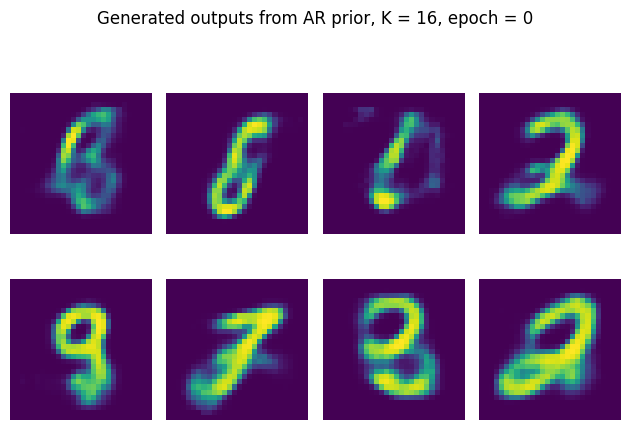

Epoch: 1, val nll=20.8324
Epoch: 2, val nll=20.6606
Epoch: 3, val nll=20.5404
Epoch: 4, val nll=20.4401
Epoch: 5, val nll=20.3430
Epoch: 6, val nll=20.2883
Epoch: 7, val nll=20.2058
Epoch: 8, val nll=20.1596
Epoch: 9, val nll=20.1063
Epoch: 10, val nll=20.0570


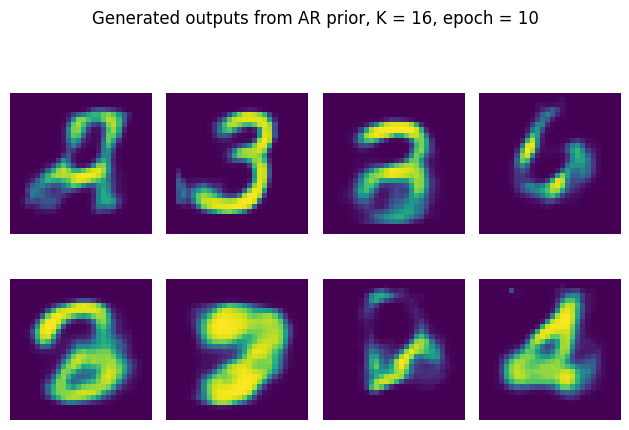

Epoch: 11, val nll=20.0177
Epoch: 12, val nll=19.9732
Epoch: 13, val nll=19.9461
Epoch: 14, val nll=19.9237
Epoch: 15, val nll=19.9024
Epoch: 16, val nll=19.8691
Epoch: 17, val nll=19.8241
Epoch: 18, val nll=19.8142
Epoch: 19, val nll=19.8050
Epoch: 20, val nll=19.7797


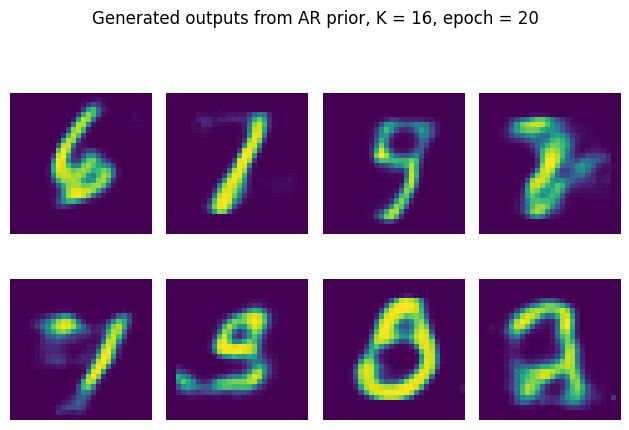

Epoch: 21, val nll=19.7410
Epoch: 22, val nll=19.7355
Epoch: 23, val nll=19.7095
Epoch: 24, val nll=19.7018
Epoch: 25, val nll=19.7067
Epoch: 26, val nll=19.6668
Epoch: 27, val nll=19.6824
Epoch: 28, val nll=19.6424
Epoch: 29, val nll=19.6721
Epoch: 30, val nll=19.6329


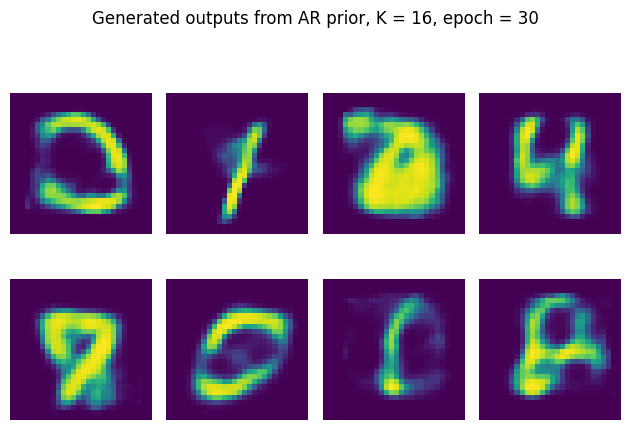

Epoch: 31, val nll=19.6374
Epoch: 32, val nll=19.6345
Epoch: 33, val nll=19.6263
Epoch: 34, val nll=19.6156
Epoch: 35, val nll=19.6248
Epoch: 36, val nll=19.6024
Epoch: 37, val nll=19.5691
Epoch: 38, val nll=19.5600
Epoch: 39, val nll=19.5775
Epoch: 40, val nll=19.5563


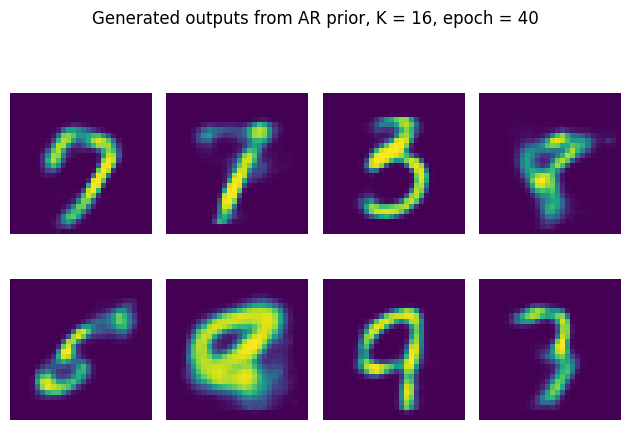

Epoch: 41, val nll=19.5756
Epoch: 42, val nll=19.5845
Epoch: 43, val nll=19.5691
Epoch: 44, val nll=19.5476
Epoch: 45, val nll=19.5485
Epoch: 46, val nll=19.5323
Epoch: 47, val nll=19.5448
Epoch: 48, val nll=19.5423
Epoch: 49, val nll=19.5643
Epoch: 50, val nll=19.5651


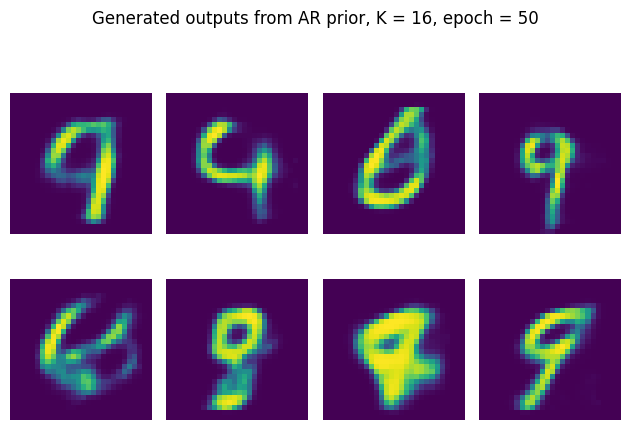

Epoch: 51, val nll=19.5441
Epoch: 52, val nll=19.4868
Epoch: 53, val nll=19.5429
Epoch: 54, val nll=19.5405
Epoch: 55, val nll=19.5360
Epoch: 56, val nll=19.4980
Epoch: 57, val nll=19.5439
Epoch: 58, val nll=19.4871
Epoch: 59, val nll=19.5425
Epoch: 60, val nll=19.4968


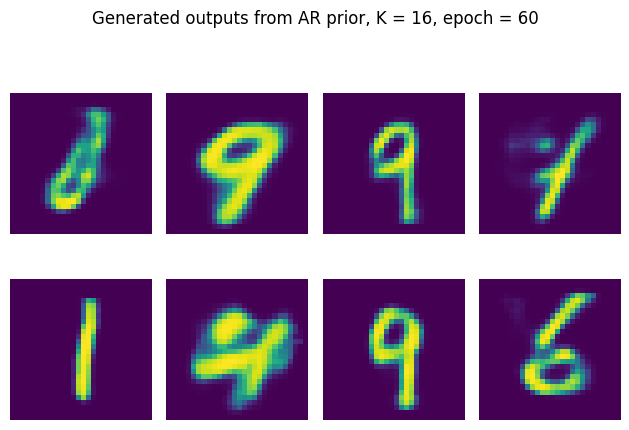

Epoch: 61, val nll=19.4965
Epoch: 62, val nll=19.4720
Epoch: 63, val nll=19.5298
Epoch: 64, val nll=19.5188
Epoch: 65, val nll=19.4905
Epoch: 66, val nll=19.4899
Epoch: 67, val nll=19.4801
Epoch: 68, val nll=19.4837
Epoch: 69, val nll=19.5035
Epoch: 70, val nll=19.4697


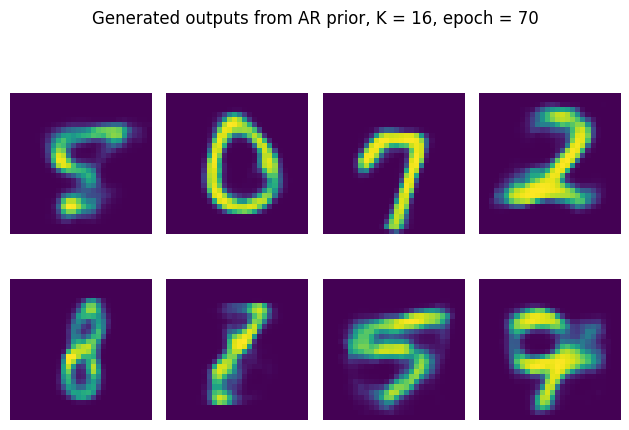

Epoch: 71, val nll=19.4921
Epoch: 72, val nll=19.4739
Epoch: 73, val nll=19.4626
Epoch: 74, val nll=19.4593
Epoch: 75, val nll=19.4714
Epoch: 76, val nll=19.4543
Epoch: 77, val nll=19.4856
Epoch: 78, val nll=19.4796
Epoch: 79, val nll=19.4914
Epoch: 80, val nll=19.5206


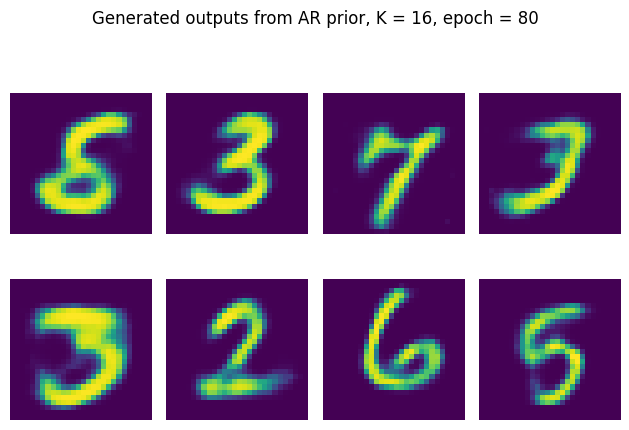

Epoch: 81, val nll=19.4700
Epoch: 82, val nll=19.4989
Epoch: 83, val nll=19.4527
Epoch: 84, val nll=19.4725
Epoch: 85, val nll=19.4374
Epoch: 86, val nll=19.4573
Epoch: 87, val nll=19.4881
Epoch: 88, val nll=19.4613
Epoch: 89, val nll=19.4468
Epoch: 90, val nll=19.4676


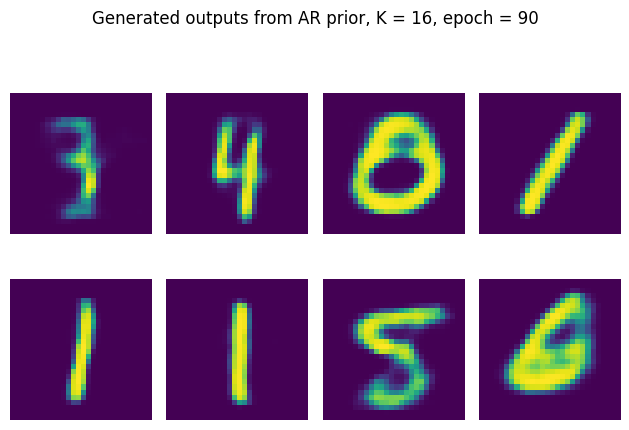

Epoch: 91, val nll=19.4925
Epoch: 92, val nll=19.4666
Epoch: 93, val nll=19.4696
Epoch: 94, val nll=19.4773
Epoch: 95, val nll=19.4668
Epoch: 96, val nll=19.4656
Epoch: 97, val nll=19.4559
Epoch: 98, val nll=19.4726
Epoch: 99, val nll=19.4648
Epoch: 100, val nll=19.4605


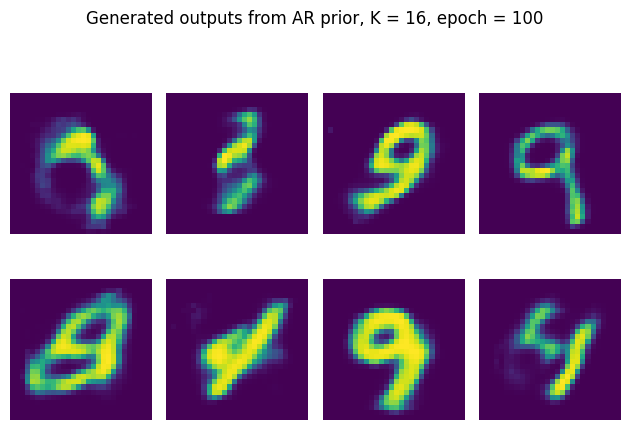

Epoch: 101, val nll=19.4401
Epoch: 102, val nll=19.4785
Epoch: 103, val nll=19.4585
Epoch: 104, val nll=19.4398
Epoch: 105, val nll=19.4278
Epoch: 106, val nll=19.4419
Epoch: 107, val nll=19.4534
Epoch: 108, val nll=19.4630
Epoch: 109, val nll=19.4534
Epoch: 110, val nll=19.4475


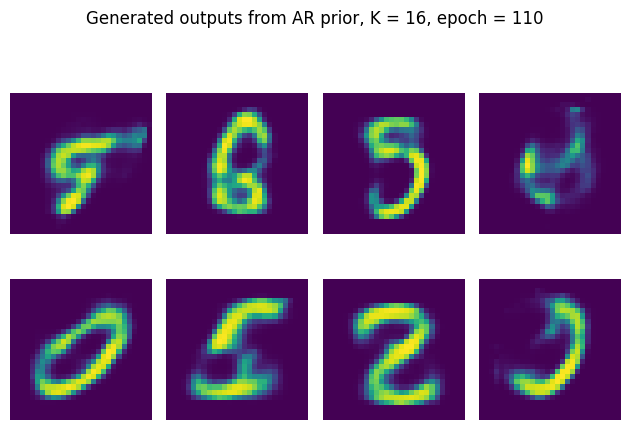

Epoch: 111, val nll=19.4365
Epoch: 112, val nll=19.4789
Epoch: 113, val nll=19.4497
Epoch: 114, val nll=19.4236
Epoch: 115, val nll=19.4659
Epoch: 116, val nll=19.4378
Epoch: 117, val nll=19.4486
Epoch: 118, val nll=19.4176
Epoch: 119, val nll=19.4593
Epoch: 120, val nll=19.4500


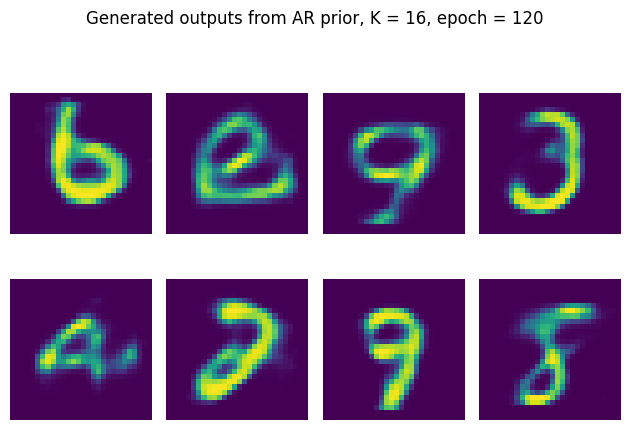

Epoch: 121, val nll=19.4491
Epoch: 122, val nll=19.4360
Epoch: 123, val nll=19.4252
Epoch: 124, val nll=19.4670
Epoch: 125, val nll=19.4480
Epoch: 126, val nll=19.4840
Epoch: 127, val nll=19.4333
Epoch: 128, val nll=19.4873
Epoch: 129, val nll=19.4403
Epoch: 130, val nll=19.4534


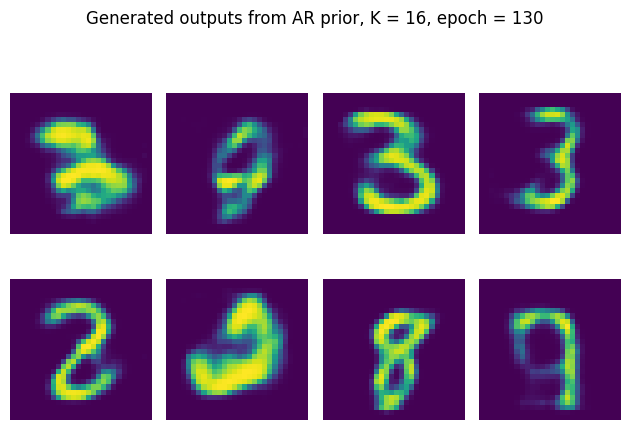

Epoch: 131, val nll=19.4493
Epoch: 132, val nll=19.4615
Epoch: 133, val nll=19.4483
Epoch: 134, val nll=19.4761
Epoch: 135, val nll=19.4051
Epoch: 136, val nll=19.4677
Epoch: 137, val nll=19.4358
Epoch: 138, val nll=19.4564
Epoch: 139, val nll=19.4407
Epoch: 140, val nll=19.4597


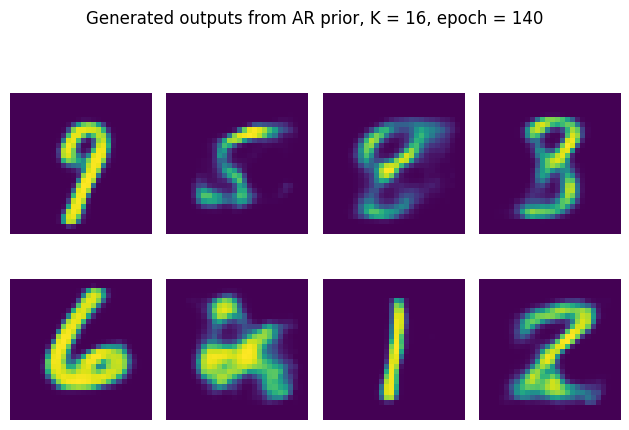

Epoch: 141, val nll=19.4834
Epoch: 142, val nll=19.4398
Epoch: 143, val nll=19.4705
Epoch: 144, val nll=19.4544
Epoch: 145, val nll=19.4512
Epoch: 146, val nll=19.4423
Epoch: 147, val nll=19.4686
Epoch: 148, val nll=19.4571
Epoch: 149, val nll=19.4460


In [47]:
#choose certain model to test the AR prior
K = 16
beta = 0.25
saved_path = f"{result_dir}{name}_K{K}_beta{beta}.pt"
vqvae, _ = load_prev_model(K, beta, saved_path)


for p in vqvae.parameters():
    p.requires_grad = False
vqvae.eval()

arm_hdim = 128    # hidden layer dimensionality for AR prior
kernel = 3        # causal conv kernel size
lr_arm = 1e-3
num_epochs_arm = 150

prior_net = nn.Sequential(
    CausalConv1d(in_channels=1, out_channels=arm_hdim, dilation=1, kernel_size=kernel, A=True),
    nn.LeakyReLU(),
    CausalConv1d(in_channels=arm_hdim, out_channels=arm_hdim, dilation=1, kernel_size=kernel, A=False),
    nn.LeakyReLU(),
    CausalConv1d(in_channels=arm_hdim, out_channels=arm_hdim, dilation=1, kernel_size=kernel, A=False),
    nn.LeakyReLU(),
    CausalConv1d(in_channels=arm_hdim, out_channels=K, dilation=1, kernel_size=kernel, A=False)
)

ar_prior = ARPrior(prior_net, num_latents=num_latents, K=K)

optimizer_arm = torch.optim.Adam([p for p in ar_prior.parameters() if p.requires_grad == True], lr=lr_arm)

nll_prior = training_ar_prior(name=result_dir + name, num_epochs=num_epochs_arm, vqvae=vqvae,
                              ar_prior=ar_prior, optimizer=optimizer_arm,
                              training_loader=training_loader, val_loader=val_loader)


#TODO: only print every ~10 epochs 

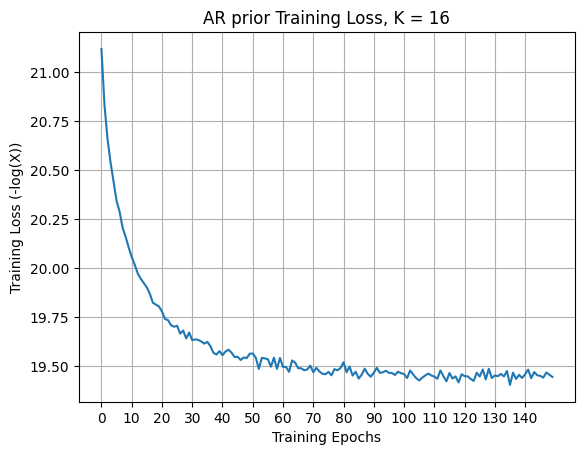

In [49]:
# TODO: Visualize autoregressive prior model training process
# NLL loss over full trianing

fig = plt.figure()
plt.plot(nll_prior)
plt.xlabel("Training Epochs")
plt.ylabel("Training Loss (-log(X))")
plt.title(f"AR prior Training Loss, K = {K}")
plt.xticks(np.arange(0,num_epochs_arm,10))
plt.grid()
plt.show()
fig.savefig(plot_folder+f"ar_prior_train_loss_{K}.png")



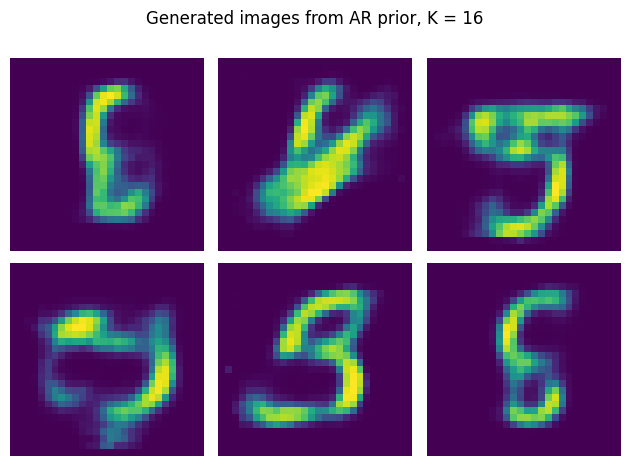

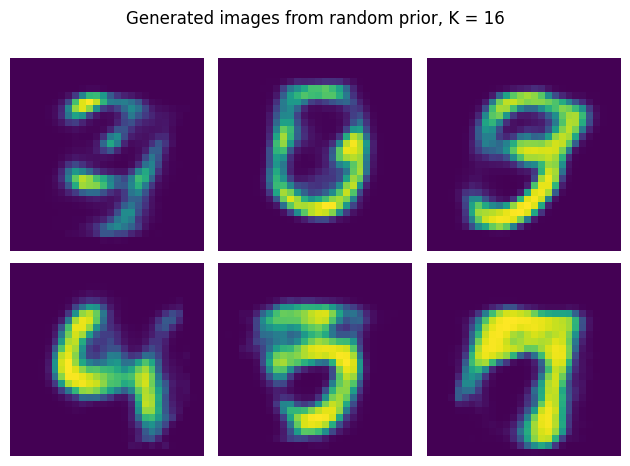

In [50]:
# TODO: Generate final samples from the full model.
# Sample index sequences from the AR prior, then decode with the frozen VQ-VAE decoder.

num_samples = 6
sampled_indices = ar_prior.sample(num_samples)
output_samples = vqvae.decode_indices(sampled_indices)

reconstructed_images = output_samples.reshape(-1,image_dim, image_dim).detach().numpy()

# TODO: Visualize the final samples from the full model.
fig, axs = plt.subplots(int(np.ceil(num_samples/3)),3,layout = "tight")
for i in range(int(np.ceil(num_samples/3))):
    for j in range(3):
        axs[i][j].imshow(reconstructed_images[i*3+j])
        axs[i][j].axis("off")
plt.suptitle(f"Generated images from AR prior, K = {K}")
plt.show()
fig.savefig(plot_folder+f"ar_prior_generations_{K}.png")


#ADDITIONAL: generation with randomly drawn indices, no prior
random_indices = torch.randint(0, K, (num_samples, num_latents))
random_output = vqvae.decode_indices(random_indices)

random_reconstructions = random_output.reshape(-1, 28, 28)
fig, axs = plt.subplots(int(np.ceil(num_samples/3)),3,layout = "tight")
for i in range(int(np.ceil(num_samples/3))):
    for j in range(3):
        axs[i][j].imshow(random_reconstructions[i*3+j])
        axs[i][j].axis("off")
plt.suptitle(f"Generated images from random prior, K = {K}")
plt.show()
fig.savefig(plot_folder+f"random_generations_{K}.png")

